In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df1=pd.read_csv('/content/final_dataset.csv')
df1.head()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,1,2021,0,5,408.80,442.42,160.61,12.95,2.77,43.19,462
1,2,1,2021,0,6,404.04,561.95,52.85,5.18,2.60,16.43,482
2,3,1,2021,1,7,225.07,239.04,170.95,10.93,1.40,44.29,263
3,4,1,2021,0,1,89.55,132.08,153.98,10.42,1.01,49.19,207
4,5,1,2021,0,2,54.06,55.54,122.66,9.70,0.64,48.88,149


In [ ]:
df1.shape

(1461, 12)

In [ ]:
df1.isnull().sum()

,0
Date,0
Month,0
Year,0
Holidays_Count,0
Days,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0


In [ ]:
df1['Year'].value_counts()

,count
Year,
2024,366
2021,365
2022,365
2023,365


In [ ]:
print(df1.head())


   Date  Month  Year  Holidays_Count  Days   PM2.5    PM10     NO2    SO2  \
0     1      1  2021               0     5  408.80  442.42  160.61  12.95   
1     2      1  2021               0     6  404.04  561.95   52.85   5.18   
2     3      1  2021               1     7  225.07  239.04  170.95  10.93   
3     4      1  2021               0     1   89.55  132.08  153.98  10.42   
4     5      1  2021               0     2   54.06   55.54  122.66   9.70   

     CO  Ozone  AQI  
0  2.77  43.19  462  
1  2.60  16.43  482  
2  1.40  44.29  263  
3  1.01  49.19  207  
4  0.64  48.88  149  


In [ ]:
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1461 non-null   int64  
 1   Month           1461 non-null   int64  
 2   Year            1461 non-null   int64  
 3   Holidays_Count  1461 non-null   int64  
 4   Days            1461 non-null   int64  
 5   PM2.5           1461 non-null   float64
 6   PM10            1461 non-null   float64
 7   NO2             1461 non-null   float64
 8   SO2             1461 non-null   float64
 9   CO              1461 non-null   float64
 10  Ozone           1461 non-null   float64
 11  AQI             1461 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 137.1 KB
None


In [ ]:
print(df1.describe())

              Date        Month         Year  Holidays_Count         Days  \
count  1461.000000  1461.000000  1461.000000     1461.000000  1461.000000   
mean     15.729637     6.522930  2022.501027        0.189596     4.000684   
std       8.803105     3.449884     1.118723        0.392116     2.001883   
min       1.000000     1.000000  2021.000000        0.000000     1.000000   
25%       8.000000     4.000000  2022.000000        0.000000     2.000000   
50%      16.000000     7.000000  2023.000000        0.000000     4.000000   
75%      23.000000    10.000000  2024.000000        0.000000     6.000000   
max      31.000000    12.000000  2024.000000        1.000000     7.000000   

             PM2.5         PM10          NO2          SO2           CO  \
count  1461.000000  1461.000000  1461.000000  1461.000000  1461.000000   
mean     90.774538   218.219261    37.184921    20.104921     1.025832   
std      71.650579   129.297734    35.225327    16.543659     0.608305   
min       

In [ ]:
df1.drop_duplicates(inplace=True)

In [ ]:
df1.isnull().sum()

,0
Date,0
Month,0
Year,0
Holidays_Count,0
Days,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0


In [ ]:
df1["DateTime"]=pd.to_datetime(df1[["Year","Month","Days"]])

In [ ]:
df1["DayOfWeek"]=df1["DateTime"].dt.dayofweek
df1["Quarter"]=df1["DateTime"].dt.quarter
df1["Weekend"]=df1["DayOfWeek"].isin([5,6]).astype(int)

In [ ]:
df1["Total_Pollution"]=(df1["PM2.5"]+df1["PM10"]+df1["NO2"]+df1["SO2"]+df1["CO"]+df1["Ozone"])

df1["PM_Ratio"]=df1["PM2.5"]/(df1["PM10"]+1)

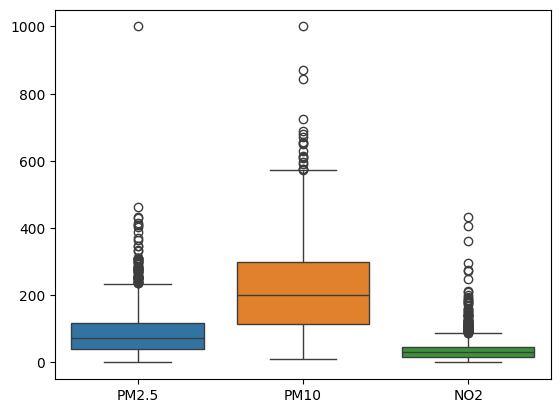

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df1[["PM2.5","PM10","NO2"]])
plt.show()

In [ ]:
df1["PM2.5"]=np.log1p(df1["PM2.5"])
df1["PM10"]=np.log1p(df1["PM10"])
df1["NO2"]=np.log1p(df1["NO2"])

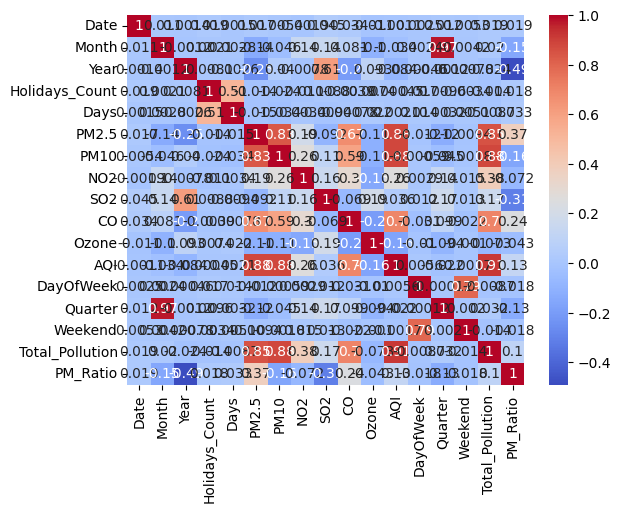

In [ ]:
sns.heatmap(df1.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

In [ ]:
X=df1.drop(columns=["AQI","DateTime"])
y=df1["AQI"]

In [ ]:
print(X.columns.to_list())

['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'DayOfWeek', 'Quarter', 'Weekend', 'Total_Pollution', 'PM_Ratio']


In [ ]:
df1['Days'].value_counts()

,count
Days,
5,209
6,209
7,209
1,209
2,209
3,208
4,208


In [ ]:
X = X.drop(columns=['Days'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1168, 15)
(293, 15)
(1168,)
(293,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2  :", r2_score(y_test, lr_pred))

Linear Regression
MAE : 24.358823760178954
RMSE: 32.9671988412846
R2  : 0.9162465610440951


In [ ]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree")
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2  :", r2_score(y_test, dt_pred))

Decision Tree
MAE : 27.273037542662117
RMSE: 39.79156444125556
R2  : 0.8779829329293608


In [ ]:
rf = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 :", r2_score(y_test, rf_pred))

Random Forest
MAE : 18.771843003412968
RMSE : 28.014812190121525
R2 : 0.9395196934229273


In [ ]:
ab = AdaBoostRegressor(
    n_estimators=100,
    random_state=42
)

ab.fit(X_train, y_train)

ab_pred = ab.predict(X_test)

print("AdaBoost")
print("MAE :", mean_absolute_error(y_test, ab_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ab_pred)))
print("R2  :", r2_score(y_test, ab_pred))

AdaBoost
MAE : 27.185405555975525
RMSE: 33.71905859693856
R2  : 0.9123827868530908


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, ab_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, ab_pred))
    ],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, ab_pred)
    ]
})

print(results.sort_values(by="R2", ascending=False))

               Model        MAE       RMSE        R2
2      Random Forest  18.771843  28.014812  0.939520
0  Linear Regression  24.358824  32.967199  0.916247
3           AdaBoost  27.185406  33.719059  0.912383
1      Decision Tree  27.273038  39.791564  0.877983


Four regression models were trained and evaluated using MAE, RMSE, and R² Score. Among all models, Random Forest achieved the best performance with the lowest MAE (18.77), lowest RMSE (28.01), and the highest R² score (0.9395), indicating that it was able to explain approximately 93.95% of the variance in AQI values. This demonstrates the effectiveness of ensemble learning in capturing the complex, non-linear relationships between air pollutants and AQI.

Linear Regression was the second-best performing model, achieving an R² score of 0.9162. Although its performance was slightly lower than Random Forest, it produced reasonably accurate predictions and served as a strong baseline model. AdaBoost obtained an R² score of 0.9124, performing similarly to Linear Regression but with slightly higher prediction errors. Decision Tree showed the weakest performance among the four models, with the highest RMSE (39.79) and the lowest R² score (0.8780), suggesting that it may have overfitted the training data and generalized less effectively on unseen data.

Overall, the results indicate that Random Forest is the most suitable model for AQI prediction in this study, as it provides the highest predictive accuracy and lowest error rates. The comparison also highlights the advantage of ensemble methods over individual decision trees and traditional regression techniques for environmental data prediction tasks.